<a href="https://colab.research.google.com/github/lbenit/Floristic_map_africa/blob/main/06_Figure_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/lbenit/Floristic_map_africa.git


Cloning into 'Floristic_map_africa'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 14 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 1.35 MiB | 2.70 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [ ]:
%cd Floristic_map_africa


/content/Floristic_map_africa/Floristic_map_africa


In [ ]:
# Print working directory
import os
print(os.getcwd())

/content/Floristic_map_africa/Floristic_map_africa


In [2]:
import pandas as pd
import matplotlib.cm as cm
import textwrap
import matplotlib.pyplot as plt
import numpy as np

# Get data

In [5]:
# Load in all data
all_data=pd.read_csv('plot_data_with_all_variables.csv')

In [13]:
all_data.head()

,plot_id,UMAP1,UMAP2,UMAP3,perturbation,singularity,cluster2,cluster3,cluster4,cluster5,...,soc_stdev_0_20,soc_stdev_20_50,sulfur_extractable_mean_0_20,sulfur_extractable_mean_20_50,sulfur_extractable_stdev_0_20,sulfur_extractable_stdev_20_50,zinc_extractable_mean_0_20,zinc_extractable_mean_20_50,zinc_extractable_stdev_0_20,zinc_extractable_stdev_20_50
0,MAR_1,-0.968939,-0.574913,-0.456427,0.266667,0.200000,0,0,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MAR_10,1.234848,3.280520,0.876849,1.400000,0.066667,1,1,1,0,...,1.0,1.0,14.0,11.0,5.0,6.0,11.0,10.0,2.0,3.0
2,MAR_100,-0.912209,0.077260,-0.221219,0.200000,0.666667,0,0,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MAR_102,1.296430,3.561313,1.141701,0.866667,0.600000,1,1,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MAR_105,-0.657446,0.029933,0.825259,0.266667,0.200000,0,0,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Radar plot: Figure 3A

In [14]:
# Select variables to compare
df=all_data[['plot_id','bio12','bio04','bio16','hnd','cluster4','fire_frequency','bio01','cec_mean_0_20','sand_mean_20_50','cluster7']]


In [9]:
df.head()

,plot_id,bio12,bio04,bio16,hnd,cluster4,fire_frequency,bio01,cec_mean_0_20,sand_mean_20_50,cluster7
0,MAR_1,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,4
1,MAR_10,1288.0,2276.0,763.0,2.799988,1,18.0,230.0,26.0,54.0,0
2,MAR_100,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,4
3,MAR_102,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,0
4,MAR_105,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,4


In [15]:
# Table of cluster4
df['cluster4'].value_counts()

,count
cluster4,
1,159
0,125
2,60
3,22


In [16]:
# Choose mean or median
grouped = df.groupby("cluster4")[['bio12','bio04','bio16','hnd','fire_frequency','bio01','cec_mean_0_20','sand_mean_20_50']].mean()

# If you want medians instead:
# grouped = df.groupby("cluster4")[["bio12","bio04","bio16","hnd","bio13","bio7"]].median()

print(grouped)


                bio12        bio04       bio16        hnd  fire_frequency  \
cluster4                                                                    
0          787.142857  2801.638095  463.514286   4.579046        3.628571   
1         1138.187500  2211.968750  729.187500  10.134367        6.078125   
2          524.883333  3159.283333  287.033333   2.241664        0.333333   
3          493.363636  3085.318182  287.772727   1.240910        0.454545   

               bio01  cec_mean_0_20  sand_mean_20_50  
cluster4                                              
0         239.409524      25.142857        58.647619  
1         230.640625      23.671875        60.125000  
2         242.516667      22.416667        64.950000  
3         243.772727      25.363636        63.090909  


In [17]:
# Scale the values
scaled = grouped / grouped.max()



In [18]:
variables=['bio12','bio04','bio16','hnd','fire_frequency','bio01','cec_mean_0_20','sand_mean_20_50']

In [19]:
# Assign colors for four clusters

# Custom colors for each cluster
cluster_colors = {
    0: "#FABA39FF",
    1: "#C7EF34FF",
    2: "#F66B19FF",
    3: "#CB2A04FF"
}

# Custom names for each cluster
cluster_names = {
    0: "Miombo",
    1: "Savanna",
    2: "Androstachys",
    3: "Mopane"
}

label_map = {
    "bio12": "Mean Annual Rainfall",
    "bio04": "Temperature Seasonality",
    "bio16": "Wettest Quarter Rainfall",
    "hnd": "Height above Nearest Drainage",
    "fire_frequency": "Fire Frequency",
    "bio01": "Mean Annual Temperature",
    "cec_mean_0_20": "Cation Exchange Capacity",
    "sand_mean_20_50": "Percentage Sand"
}


In [20]:
# Custom colors for each cluster 7
cluster_colors = {
    0: "#FABA39FF",
    1: "#C7EF34FF",
    2: "#F66B19FF",
    3: "#CB2A04FF",
    4: 'Blue',
    5: 'Purple',
    6: 'Green'
}

# Custom names for each cluster
cluster_names = {
    0: "Mopane",
    1: "Cryptosepalum",
    2: "Baikiaea",
    3: "Combretum",
    4: 'Uapaca',
    5: 'Andro',
    6: 'Julbernardia'
}

label_map = {
    "bio12": "Mean Annual Rainfall",
    "bio04": "Temperature Seasonality",
    "bio16": "Wettest Quarter Rainfall",
    "hnd": "Height above Nearest Drainage",
    "fire_frequency": "Fire Frequency",
    "bio01": "Mean Annual Temperature",
    "cec_mean_0_20": "Cation Exchange Capacity",
    "sand_mean_20_50": "Percentage Sand"
}


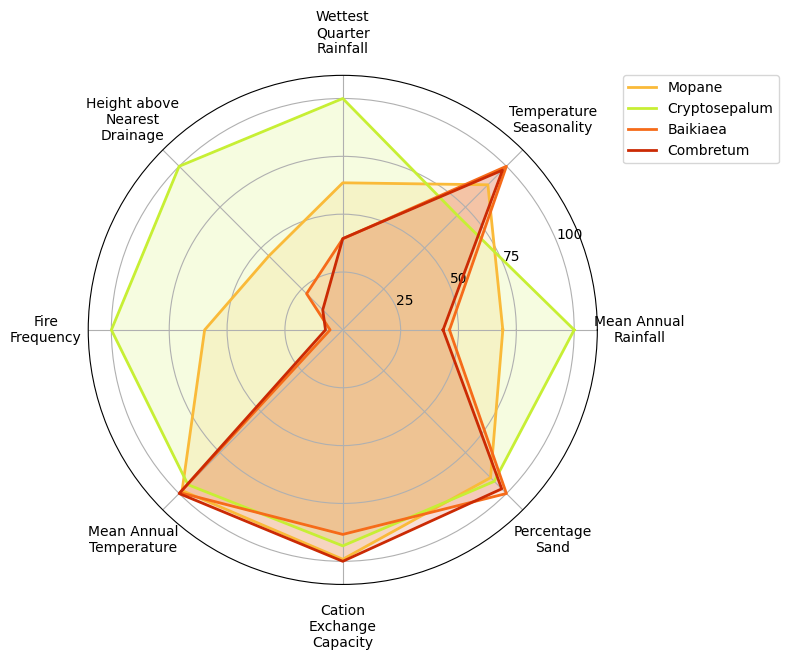

In [21]:


# Number of variables
N = len(variables)

# Angles for radar chart
angles = np.linspace(0, 2*np.pi, N, endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))

# Plot each cluster
for cluster, row in scaled.iterrows():
    values = row[variables].values
    values = np.concatenate([values, [values[0]]])

    color = cluster_colors[cluster]
    label = cluster_names[cluster]

    ax.plot(angles, values, linewidth=2, label=label, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

# -----------------------------
# WRAP LABELS
# -----------------------------
wrapped_labels = [textwrap.fill(label_map[v], width=12) for v in variables]

ax.set_xticks(angles[:-1])
ax.set_xticklabels(wrapped_labels, fontsize=10)

# Push all theta labels outward in one go
ax.tick_params(axis='x', pad=20)  # increase pad if still too close

# -----------------------------
# RADIAL SETTINGS
# -----------------------------
ax.set_ylim(0, 1.1)

ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25", "50", "75", "100"])

# -----------------------------
# LEGEND OUTSIDE PLOT
# -----------------------------
ax.legend(
    loc="upper left",
    bbox_to_anchor=(1.05, 1.0),
    borderaxespad=0.
)

plt.tight_layout()
plt.show()




# Variable importance: Figure 3B

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
###################################
# Reduce predictors
basic = ['bio01',"b12","bio04","bio16","hnd",'fire_frequency','cec_mean_0_20','sand_mean_20_50']

# Label map for nicer names
label_map = {
    "bio12": "Mean Annual Rainfall",
    "bio4": "Temperature Seasonality",
    "bio16": "Wettest Quarter Rainfall",
    "hnd": "Height above Nearest Drainage",
    "fire_frequency": "Fire Frequency",
    "bio01": "Mean Annual Temperature",
    "cec_mean_0_20": "Cation Exchange Capacity",
    "sand_mean_20_50": "Percentage Sand"
}

# 1. Use the full dataset for training
X_full = all_data[basic]
y_full = all_data["cluster4"]


# 2. Train RF on the full dataset
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_full, y_full)

# 3. Predict on the test set
y_pred = clf.predict(X_full)

# 5. Variable importance (Mean Decrease in Gini)
importances = clf.feature_importances_

imp_df = pd.DataFrame({
    "variable": basic,
    "importance": importances
}).sort_values("importance", ascending=False)

# Replace variable names using label_map
imp_df["variable_pretty"] = imp_df["variable"].map(label_map)



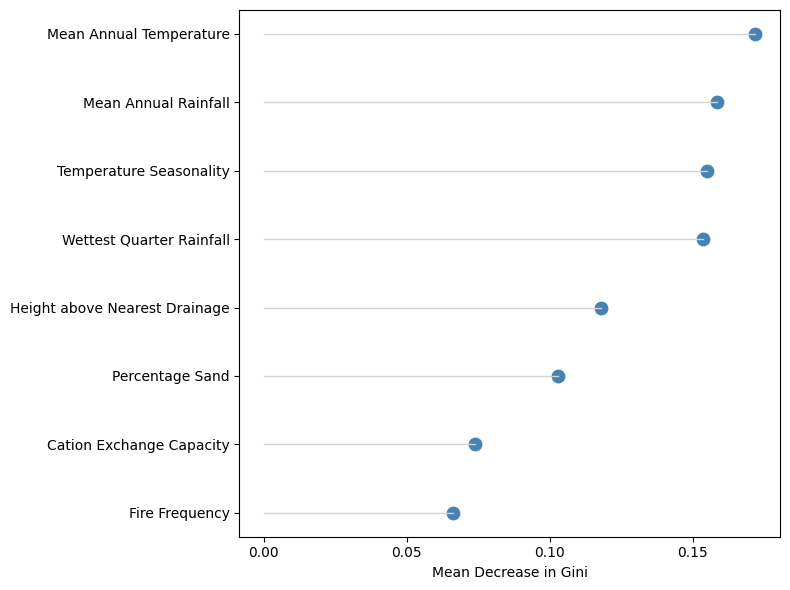

In [ ]:
# Plot gini
# 6. Plot top 10
top10 = imp_df.head(10).iloc[::-1]  # reverse for nicer barh plot

plt.figure(figsize=(8, 6))

# Scatter points
plt.scatter(top10["importance"], top10["variable_pretty"], color="steelblue", s=80)

# Optional: faint horizontal lines
for imp, var in zip(top10["importance"], top10["variable_pretty"]):
    plt.plot([0, imp], [var, var], color="lightgray", linewidth=1)

plt.xlabel("Mean Decrease in Gini")
plt.locator_params(axis="x", nbins=4)
plt.tight_layout()
plt.show()


# Log odds plot: Figure 3 C-E

In [ ]:

def log_odds_pdp(clf, X, var_name, clusters, grid_size=50):
    # Column index
    var_idx = list(X.columns).index(var_name)

    # Grid of values for the variable
    x_vals = np.linspace(X[var_name].min(), X[var_name].max(), grid_size)

    # Fix all other predictors at their mean
    X_mean = X.mean().to_frame().T

    # Storage for PDP curves
    pdp_curves = {c: [] for c in clusters}

    for v in x_vals:
        X_temp = X_mean.copy()
        X_temp.iloc[0, var_idx] = v

        # Predict probabilities
        probs = clf.predict_proba(X_temp)[0]

        # Convert to log-odds for each cluster
        for c in clusters:
            p = probs[c]
            # avoid division by zero
            p = np.clip(p, 1e-6, 1 - 1e-6)
            log_odds = np.log(p / (1 - p))
            pdp_curves[c].append(log_odds)

    return x_vals, pdp_curves

In [ ]:
def plot_log_odds_top3(clf, X, top3, clusters):

    fig, axes = plt.subplots(3, 1, figsize=(5, 12))

    for ax, var in zip(axes, top3):

        # Compute PDP curves
        x_vals, pdp_curves = log_odds_pdp(clf, X, var, clusters)

        # Plot each cluster using your chosen colors + names
        for c in clusters:
            ax.plot(
                x_vals,
                pdp_curves[c],
                color=cluster_colors[c],      # your custom color
                linewidth=2,
                label=cluster_names[c]        # your custom cluster name
            )

        # Pretty variable name from your label map
        pretty_var = label_map.get(var, var)


        ax.set_ylim(bottom=-7)
        ax.set_xlabel(pretty_var)
        ax.set_ylabel("Log-odds")

    plt.tight_layout()
    plt.show()


In [ ]:
def summarize_top3(X, top3, cluster_col="cluster"):
    for var in top3:
        summary = (
            X.groupby(cluster_col)[var]
             .agg(["min", "mean", "median", "max"])
        )
        print(f"\n=== {var} ===")
        print(summary)


In [ ]:
def plot_log_odds_top3(clf, X, top3, clusters, var_ranges):

    fig, axes = plt.subplots(3, 1, figsize=(5, 12))

    for ax, var in zip(axes, top3):

        # Compute PDP curves
        x_vals, pdp_curves = log_odds_pdp(clf, X, var, clusters)

        # Pretty variable name
        pretty_var = label_map.get(var, var)

        # Get user-specified min/max for this variable
        xmin, xmax = var_ranges[var]

        # Restrict x_vals to the chosen range
        mask = (x_vals >= xmin) & (x_vals <= xmax)

        for c in clusters:

            # Convert PDP curve to array
            y = np.asarray(pdp_curves[c])

            # Trim to user-specified range
            x_trim = x_vals[mask]
            y_trim = y[mask]

            ax.plot(
                x_trim,
                y_trim,
                color=cluster_colors[c],
                linewidth=2,
                label=cluster_names[c]
            )

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(bottom=-7)
        ax.set_xlabel(pretty_var)
        ax.set_ylabel("Log-odds")

    plt.tight_layout()
    plt.show()


In [ ]:
top3=['bio12','bio04','hnd']

summarize_top3(all_data, top3, cluster_col="cluster4")



=== b12 ===
            min         mean  median     max
cluster4                                    
0         387.0  1025.077840  1042.0  2026.0
1         349.0   893.789094   859.0  2026.0
2         368.0   721.639860   621.0  1969.0
3         336.0   801.640227   735.0  1947.0

=== b4 ===
                 min        mean     median        max
cluster4                                              
0         112.905010  238.523561  244.70221  370.80893
1          89.140480  262.294882  271.62354  392.76096
2         125.314740  277.300538  290.48648  336.94794
3         115.229515  288.430270  304.87549  372.15866

=== hnd ===
          min       mean  median    max
cluster4                               
0         0.0  24.623656    15.0  408.0
1         0.0  17.903769     9.0  447.0
2         0.0  16.989510     7.0  274.0
3         0.0  13.800283     6.0  288.0


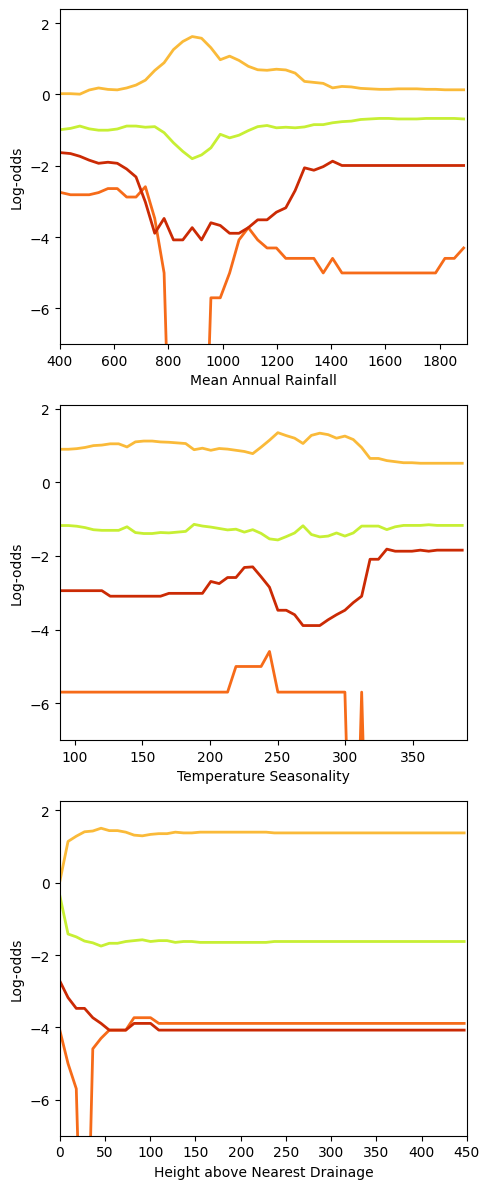

In [ ]:
# Plot top 3 variables

# Cluster labels
clusters = sorted(all_data["cluster4"].unique())

top3=['bio12','bio04','hnd']

var_ranges = {
    "bio12": (400, 1900),
    "bio044": (89, 390),
    "hnd": (0, 450)
}


# Plot log-odds PDPs
plot_log_odds_top3(clf, X_full, top3, clusters, var_ranges)